<a href="https://colab.research.google.com/github/r-okotie179/projectTantalus/blob/main/chapter_2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.5 A Stochastic Version of the Eyam Model

The first model used for Eyam was analytic and was such that no matter how many times the model was run, there would always be the same continuous function as the output.

For actual disease modelling, it would be better to model the system more randomly and with discrete agents (i.e. you cannot have half a person be infected) which is meaningful with smaller sample sizes (such as the emergence of a disease in a town).

A stochastic process is one that is sample from a random probability distribution. I will now try to understand what a Poisson distribution is and what parameters are used for this.

## The Poisson Distribution
The Poisson Distribution is the limit of the binomial distribution as $n$, the number of trials, gets large and $p$, the probabilty of an event occurring, is small.

It is typically used in modelling rare events.

The binomial distribution:
$$x \sim B(n, p)$$

$$B(x) = {n \choose x} p^{x} (1-p)^{n-x}$$

The expected value of $n$ and $p$ is $\lambda = np$. This could be rearranged into the equation to get the limit as n tends to infinity.

$${n \choose x} = \frac{n!}{x! (n-x)!}$$

The replacement of $\lambda = np$ is as follows:
$$\frac{n!}{x! (n-x)!}(\frac{\lambda}{n})^x(1-\frac{\lambda}{n})^{n-x}$$
I then got $n$ all to one fraction as shown below:
$$\lim_{n \to \infty} \frac{n! (n-\lambda)^{n-x}}{(n-x)!n^x n^{n-x}} \times \frac{\lambda^x}{x!}$$

There were parts of this that I didn't understand how to find the limit of (I needed the Gamma Funciton) but the limit equals $e^{-\lambda}$.

$$Po(x) = \lim_{n \to \infty}B(x) = e^{- \lambda} \frac{\lambda^x}{x!}$$

### SIDR Model

Susceptibles, Infective, Dead and Recovered (although in this simple model I will let the Dead = D + R)

N = S+I+D

The chance of any given infective "colliding" with someone who is suscpetible within the population is $\frac{S}{N}$. Thus the expected value across all the infectives will be $\frac{S}{N} * I$.

This implies that $\Delta S \propto \frac{SI}{N}$. Also, since although an infective, $I$, may be in contact with someone susceptible there is still an attributed probability of transmission. This is typically the reproduction number, $R_0$, of a disease and it also means that $\Delta S \propto \beta N$

Therefore (since $\Delta S \leq 0$):
$$\Delta S = - \frac{S}{N} \times I \times \beta N \Delta t$$
$$\Delta S = - \beta S I \Delta t$$

Within the group of infected people, an outcome will occur. For a simplified model, like this, everybody dies so there is no consideration of people potentially recovering and then being re-susceptible later (although this will be explored later).

Thus, there is a fraction of the infectives that die in each time step.

$$\Delta D = \alpha I \Delta t$$

Now finally, the change of infectives over a given timestep is:
$$\Delta I = (\beta SI - \alpha I) \Delta t = (\beta S - \alpha)I\Delta t$$

Since this change is dependent on the expected value (which is sampled from a random distribution across each time step). To do this I will use the Poisson distribution: for real distributions, Poissons are a good starting point but other improvements can occur. E.g. if most infectives don't actually infect anyone else and there are a few 'super-spreaders' then using a power law distribution (or piecewise function for different conditions) may be better. I'd be interested whether if a piecewise function seems appropriate, that it would be approximated using either a Fourier or Taylor series.

### Application of Poisson
$$x \sim \text{Po}(\lambda)$$

The expected value and the variance of this distribution both equal $\lambda$.

$$P(x) = \frac{\lambda^x}{x!} e^{-\lambda}$$

For each time step, since we know the expected values from the constructed differential equations, what can do this stuff.

$$\Delta S = -x, \Delta I_0 = x$$
$$x \sim \text{Po}(\beta SI \Delta t)$$


$$\Delta D = y, \Delta I_1 = -y$$
$$y \sim \text{Po}(\alpha I \Delta t)$$

$$\Delta I = x-y$$

Now a discrete numerical simulation of a disease outbreak will be written using this (and I will try to understand it further to  see I could update my understanding for constructing the cow disease model).

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
import math

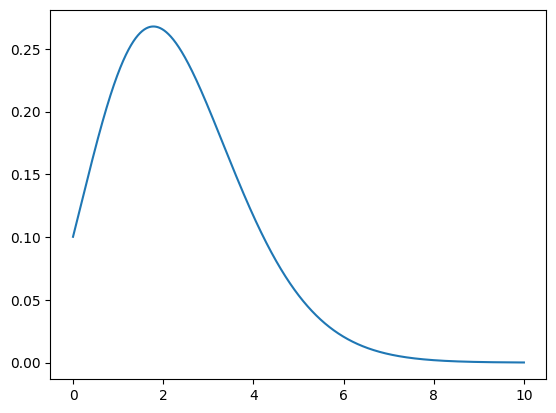

In [10]:
# quick run of the poisson distribution

def poisson(e,x):
  return ((e**x) * (np.exp(-e)))/(factorial(x))

l = np.linspace(0,10,1000000)
y = poisson(2.3, l)

plt.plot(l, y)
plt.show()

Trying to sample this distribution non-deterministically needs the construction of a pretty simple algorithm:

- create a cumulative density function (where are each integer, the area under the curve gets added)
- use an existing random number generator (between 0 and 1) and for the number where this random number is larger than the distribution, extract the value of k for which it is true.

I, however, will deal with this personal implementation later.

I will use the numbers from Andrew French's model.

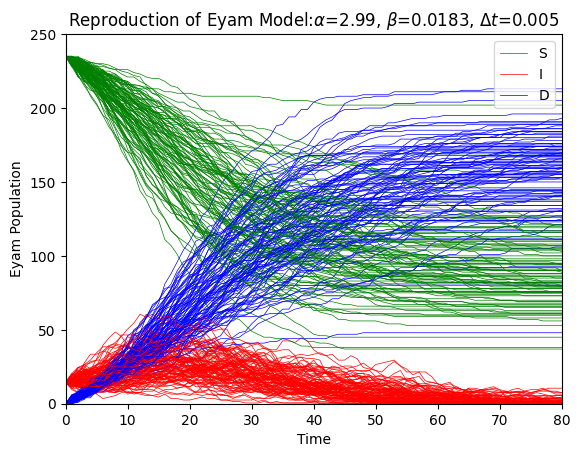

In [42]:
# constants & initial conditions
alpha = 2.99
beta = 0.0183
t = 0.05 # \Delta t

months = 4
steps = math.floor(months/t)
iterations = 100

def delta_s(s, i):
  e = beta * s * i * t # expected value
  return np.random.poisson(lam=e)

def delta_d(i):
  e = alpha * i * t
  return np.random.poisson(lam=e)

for iter in range(iterations):
  s = [235]
  i = [14.5] # only statisticians can have 2.4 children
  d = [0]

  for idx in range(steps):
    si = s[idx]
    ii = i[idx]
    di = d[idx]

    x = delta_s(si, ii) # since beta and delta t are constants
    y = delta_d(ii)

    i2 = max(0, (ii + x - y))
    s2 = max(0, (si - x))
    d2 = di + y

    s.append(s2)
    i.append(i2)
    d.append(d2)

  num_steps = range(len(s))
  plt.plot((num_steps), s, color='g', lw=0.5, label="S" if iter==0 else "")
  plt.plot((num_steps), i, color='r', lw=0.5, label="I" if iter==0 else "")
  plt.plot((num_steps), d, color='b', lw=0.5, label="D" if iter==0 else "")

plt.title(r"Reproduction of Eyam Model:$\alpha$=2.99, $\beta$=0.0183, $\Delta t$=0.005")
plt.xlim(0, max(num_steps))
plt.ylim(0, 250)
plt.legend(loc="upper right")
plt.xlabel("Time")
plt.ylabel("Eyam Population")
plt.show()

As an extension, I will try to do the heatmap effect he did in the paper (and just write a function that I can use for future projects since I do find stochastic models as a better technique for stuff I do).

### Heatmap of Stochastic Plots
*I will try to derive how to break down plot such such a heatmap can be formed. Sketches of intentions will first be made before progression.*